## Plant Disease Detection Computer Vision Project By Awwab Hamdatu (202201754).

---


### Supervision of Dr. Anwar Majid Mirza.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Configurations:

I am using OpenCV to perform the "surgery" on the leaves (cutting out the spots), and Scikit-Learn to handle the heavy mathematical work (PCA, GMM, SVM).

I also set the "Hyperparameters" here. These numbers have been tuned several times during many experiments. I ended up choosing 24 Eigen-Lesions (capturing ~90% of spot variance) and 64 Fisher Clusters (to give us a rich vocabulary of disease types).

In [3]:
import os
import shutil
import requests
import zipfile
import cv2
import numpy as np
import random
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm

# Machine Learning Libraries
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# --- PROJECT CONFIGURATION ---
DATA_ROOT = '/content/plant_village_data'
# The standard path where the robust downloader extracts files
IMAGE_DIR = os.path.join(DATA_ROOT, 'PlantVillage-Dataset-master', 'raw', 'color')

# Hyperparameters
N_PCA_COMPONENTS = 24   # Number of "Eigen-Lesions" (Basis Vectors of our space)
N_GMM_COMPONENTS = 64   # Number of "Visual Words" in our Fisher Vocabulary
MAX_IMAGES_PER_CLASS = None # Set to None for the FULL dataset run
SEED = 42

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
print("Configuration Loaded. Ready to start.")

Configuration Loaded. Ready to start.


## Force Download The PlantVillage Dataset:

This cell forces a download of the PlantVillage dataset from a specific GitHub repository. It includes safety checks: if the folder already exists, it deletes it and starts fresh to ensure we don't have corrupted files. It unzips the data and prepares the directory for the analysis. I added this sort of "aggressive" dataset installation because Colab notebooks can sometimes be very stingy when downloading datasets from my previous experience.

In [4]:
def force_download_plantvillage(root_dir):
    """
    Downloads the PlantVillage dataset.
    Cleans up old attempts to ensure a fresh, uncorrupted dataset.
    """
    repo_url = "https://github.com/spMohanty/PlantVillage-Dataset/archive/refs/heads/master.zip"
    archive_path = os.path.join(root_dir, 'dataset.zip')

    # 1. Clean up existing data
    if os.path.exists(root_dir):
        print(f"[CleanUp] Removing existing directory: {root_dir}")
        shutil.rmtree(root_dir)
    os.makedirs(root_dir, exist_ok=True)

    # 2. Download
    print(f"[Download] Grabbing dataset from {repo_url}...")
    try:
        r = requests.get(repo_url, stream=True)
        with open(archive_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024):
                if chunk: f.write(chunk)
    except Exception as e:
        raise RuntimeError(f"Download failed: {e}")

    # 3. Extract
    print("[Extract] Unzipping payload...")
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(root_dir)

    # 4. Cleanup Zip
    os.remove(archive_path)
    print("[Success] Dataset ready.")

# Execute the download
if not os.path.exists(IMAGE_DIR):
    force_download_plantvillage(DATA_ROOT)
else:
    print(f"Data already exists at {IMAGE_DIR}")

[Download] Grabbing dataset from https://github.com/spMohanty/PlantVillage-Dataset/archive/refs/heads/master.zip...
[Extract] Unzipping payload...
[Success] Dataset ready.


##Cell 3: The Setup Functions (The Core Logic):
The Explanation: This is the main working block of the whole project. It contains three functions:

###extract_lesion_candidates:
 I call this part the "Surgeon." It uses Lab Color Space math to surgically remove the healthy green leaf and isolate the disease spots (lesions).

###extract_global_features:
 It calculates the average color and texture of the leaf, helping the model distinguish between a healthy green leaf and a yellowing sick leaf. In my very first run of this idea, before having implemented this function, the results for some leafs were very poor. Implementing this function alone added around an extra 12.4% accuracy with little extra compute cost.

###fisher_vector:
 This implements the Fisher Vector encoding, which measures not just count of spots, but how those spots deviate from the average. Initially, I had used K-Means Clustering with a "Bag of Features" approach since it is computationally much lighter and directly related to what we have taken so far in the course. However, after testing the fisher_vector method with GMM instead of K-Means, the results were simply too good to go back. It was only for a few secondds, but you did mention "Fisher" in one of our latest classes, so I do somewhat consider this to be part of the course material.

In [5]:
# 1. Lesion Extraction:
def extract_lesion_candidates(image_path):
    """
    Uses Lab Color Space to separate 'Green' (Healthy) from 'Not Green' (Disease).
    Returns a list of 32x32 cropped lesion images.
    """
    img = cv2.imread(image_path)
    if img is None: return []
    img = cv2.resize(img, (256, 256))

    # Convert to LAB (Lightness, A=Green-Red, B=Blue-Yellow)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # 1. Green Filter: Healthy leaves have low 'A' values.
    # We invert this to find the "Not Green" parts.
    _, green_mask = cv2.threshold(a, 120, 255, cv2.THRESH_BINARY_INV)

    # 2. Leaf Filter: Remove the background (Low Saturation)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s = hsv[:,:,1]
    _, leaf_area_mask = cv2.threshold(s, 25, 255, cv2.THRESH_BINARY)

    # 3. Combine: Disease = (Not Green) AND (Is Leaf)
    disease_mask = cv2.bitwise_and(cv2.bitwise_not(green_mask), leaf_area_mask)

    # 4. Clean up noise
    kernel = np.ones((3,3), np.uint8)
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    contours, _ = cv2.findContours(disease_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lesion_crops = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        # Filter: Ignore tiny noise dots and massive segmentation errors
        if 10 < area < 1000:
            x, y, w, h = cv2.boundingRect(cnt)
            roi = img[y:y+h, x:x+w]
            try:
                # Standardize to 32x32 pixels
                roi_resized = cv2.resize(roi, (32, 32), interpolation=cv2.INTER_AREA)
                lesion_crops.append(roi_resized)
            except: pass
    return lesion_crops

# 2. Global Color Features:
def extract_global_features(image_path):
    """
    Calculates Mean and StdDev of Color channels (Lab) for the leaf area only.
    """
    img = cv2.imread(image_path)
    if img is None: return np.zeros(6)
    img = cv2.resize(img, (256, 256))
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Find leaf area using Saturation
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = hsv[:,:,1] > 25

    if np.sum(mask) == 0: return np.zeros(6)

    # Return normalized statistics (Mean L, Mean A, Mean B, Std L, Std A, Std B)
    return np.array([np.mean(l[mask]), np.mean(a[mask]), np.mean(b[mask]),
                     np.std(l[mask]), np.std(a[mask]), np.std(b[mask])]) / 255.0

# 3. Fisher Vector Encoding:
def fisher_vector(xx, gmm):
    """
    Computes Fisher Vector gradients for a set of descriptors (xx) against a GMM.
    """
    xx = np.atleast_2d(xx)
    N = xx.shape[0]

    # Posterior Probabilities (Soft Assignment)
    Q = gmm.predict_proba(xx)  # (N, N_clusters)

    # Sufficient Statistics
    Q_sum = np.sum(Q, 0)[:, np.newaxis]
    Q_xx = np.dot(Q.T, xx)
    Q_xx_2 = np.dot(Q.T, xx ** 2)

    # GMM Parameters
    means = gmm.means_
    sigmas = gmm.covariances_
    weights = gmm.weights_

    # Derivatives w.r.t Mean and Variance
    d_mu = (Q_xx - Q_sum * means) / np.sqrt(weights[:, np.newaxis] * sigmas)
    d_sigma = (Q_xx_2 - 2 * Q_xx * means + Q_sum * means**2 - Q_sum * sigmas) / np.sqrt(2 * weights[:, np.newaxis] * sigmas**2)

    # Flatten into a single long vector
    return np.hstack((d_mu.flatten(), d_sigma.flatten()))

##Cell 4: Loading the File List
A simple walk through the dataset folders, counting the images, and identifying the class names (e.g., Tomato___Early_Blight).

In [6]:
def get_image_paths_and_labels(root_dir):
    classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    paths, labels = [], []

    print(f"[Data] Found {len(classes)} classes.")
    for c in classes:
        class_dir = os.path.join(root_dir, c)
        files = glob(os.path.join(class_dir, '*.JPG'))

        if MAX_IMAGES_PER_CLASS: files = files[:MAX_IMAGES_PER_CLASS]

        paths.extend(files)
        labels.extend([c]*len(files))

    return paths, labels, classes

all_paths, all_labels, class_names = get_image_paths_and_labels(IMAGE_DIR)
print(f"[Data] Total images loaded: {len(all_paths)}")

[Data] Found 38 classes.
[Data] Total images loaded: 52803


##Cell 5: Phase 1 - Training PCA (Eigen-Lesions)
We need to learn the "Alphabet" of plant diseases. We extract disease spots from a random subset of 5,000 images and feed them into PCA (Principal Component Analysis). The result is a set of "Eigen-Lesions". This is practically just "EigenFaces" but with Lesions of diseased plants. They fundamental visual building blocks that make up a disease spot, and a linear combination of these Eigen-Lesions can theoretically model any of the other Lesions in our dataset.

In [8]:
training_spots = []
# Take a robust sample of 1000 images to learn the basis vectors
subset_paths = random.sample(all_paths, min(len(all_paths), 5000))

print(f"[PCA] Harvesting spots from {len(subset_paths)} images...")
for path in tqdm(subset_paths):
    spots = extract_lesion_candidates(path)
    for s in spots:
        # Flatten 32x32x3 -> 3072 x 1 vector
        training_spots.append(s.flatten())

X_pca_train = np.array(training_spots)
print(f"[PCA] Fitting on {X_pca_train.shape[0]} spots...")

# Whiten=True normalizes the variance, which is crucial for the next step (GMM)
pca_model = PCA(n_components=N_PCA_COMPONENTS, whiten=True)
pca_model.fit(X_pca_train)

print(f"[PCA] Explained Variance: {sum(pca_model.explained_variance_ratio_):.2f}")

[PCA] Harvesting spots from 5000 images...


100%|██████████| 5000/5000 [00:12<00:00, 401.45it/s]


[PCA] Fitting on 85480 spots...
[PCA] Explained Variance: 0.91


##Cell 6: Visualizing the "Ghost Lesions"
This is simply a visualization tool to include the visual in the research document. Here, we visualize the "Eigen-Lesions" we just learned. We also plot that same plot within our "Eigenfaces slides" that shows how to pick the (K) dimension (How many eigenfaces to use) to show that our choice of 24 components captures the majority (90%+) of the relevant visual information and that going with any amount beyond that will add extra compute while giving back very diminishing results.

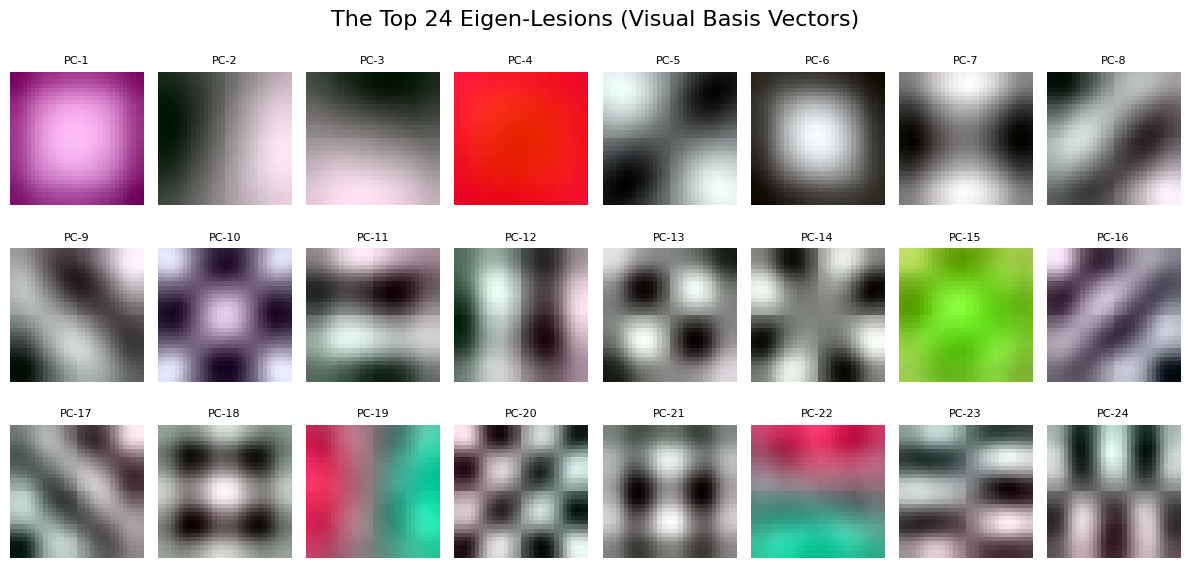

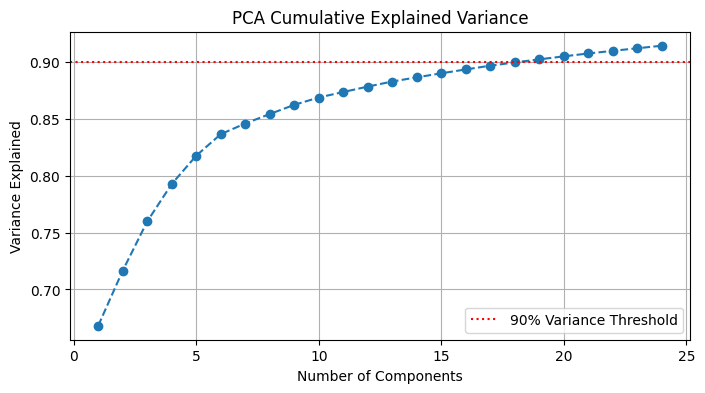

In [9]:
# VISUALIZATION: EIGEN-LESIONS
plt.figure(figsize=(12, 6))
plt.suptitle(f"The Top {N_PCA_COMPONENTS} Eigen-Lesions (Visual Basis Vectors)", fontsize=16)

rows = 3
cols = 8

for i in range(N_PCA_COMPONENTS):
    ax = plt.subplot(rows, cols, i+1)
    # Reshape the flat vector back to 32x32x3 image so we can actually plot it as an image.
    img = pca_model.components_[i].reshape(32, 32, 3)
    # Normalize to 0-1 for display
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"PC-{i+1}", fontsize=8)
plt.tight_layout()
plt.show()

# VISUALIZATION: THE PLOT
plt.figure(figsize=(8, 4))
cum_var = np.cumsum(pca_model.explained_variance_ratio_)
plt.plot(range(1, N_PCA_COMPONENTS+1), cum_var, marker='o', linestyle='--')
plt.axhline(y=0.9, color='r', linestyle=':', label='90% Variance Threshold')
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.legend()
plt.grid()
plt.show()

##Cell 7: Phase 2 - Training GMM (Fisher Vocabulary)
-We project thousands of spots into our new PCA space and group them using a Gaussian Mixture Model (GMM). This creates 64 "clusters" of disease types (e.g., one cluster might be "Dark Necrotic Spots," another might be "Yellow Halos").

-Again, I did initially use a "Bag of features" approach to make sure that my project coincides with the material as much as possible, but this was much more effective.

In [10]:
gmm_spots = []
# Need a larger sample to fill 64 clusters adequately
subset_for_gmm = random.sample(all_paths, min(len(all_paths), 5000))

print(f"[GMM] Harvesting spots from {len(subset_for_gmm)} images...")
for path in tqdm(subset_for_gmm):
    spots = extract_lesion_candidates(path)
    for s in spots:
        # Project spot into PCA space (dimensionality reduction)
        vec = pca_model.transform([s.flatten()])
        gmm_spots.append(vec[0])

X_gmm = np.array(gmm_spots)
print(f"[GMM] Fitting Gaussian Mixture on {X_gmm.shape[0]} spots...")

# Diagonal covariance for Fisher Vectors (saves compute)
gmm_model = GaussianMixture(n_components=N_GMM_COMPONENTS, covariance_type='diag', random_state=SEED)
gmm_model.fit(X_gmm)
print("[GMM] Vocabulary Learned.")

[GMM] Harvesting spots from 5000 images...


100%|██████████| 5000/5000 [00:47<00:00, 105.26it/s]


[GMM] Fitting Gaussian Mixture on 85942 spots...
[GMM] Vocabulary Learned.


##Cell 8: Visualizing the Dictionary
This is yet again just a visualization tool. We take the center of each GMM cluster and "inverse transform" it back into an image. This shows us the "Average Spot" for each word in our vocabulary.



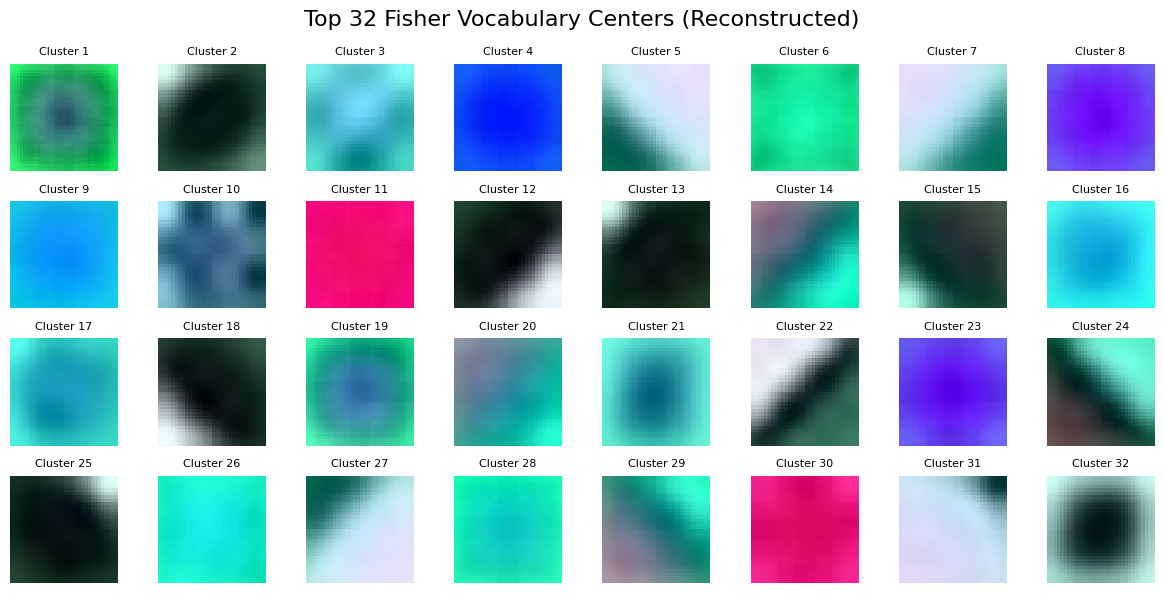

In [11]:
# --- VISUALIZATION: FISHER CENTERS ---
plt.figure(figsize=(12, 6))
plt.suptitle(f"Top 32 Fisher Vocabulary Centers (Reconstructed)", fontsize=16)

# Show first 32 clusters
for i in range(min(32, N_GMM_COMPONENTS)):
    ax = plt.subplot(4, 8, i+1)
    # Inverse transform: PCA Vector -> Original Image Space
    vec = pca_model.inverse_transform(gmm_model.means_[i])
    img = vec.reshape(32, 32, 3)
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Cluster {i+1}", fontsize=8)
plt.tight_layout()
plt.show()

##Cell 9: Phase 3 - Feature Extraction (The Main Loop)
We iterate through every single image in the dataset. For each image, we:

-Extract the spots.

-Calculate the Fisher Vector (representing the lesions).

-Calculate the Global Color (representing the leaf context).

-Combine them into one massive "Fingerprint" vector for that image.

In [12]:
X_final = []
y_final = []

print("Extracting Fisher Vectors + Global Color for all images...")
for path, label in tqdm(zip(all_paths, all_labels), total=len(all_paths)):

    # 1. Lesion Features (Fisher Vector)
    spots = extract_lesion_candidates(path)

    # Dimension = 2 * K * D (Fisher standard)
    fv_dim = 2 * N_GMM_COMPONENTS * N_PCA_COMPONENTS
    fv = np.zeros(fv_dim)

    if len(spots) > 0:
        flat_spots = [s.flatten() for s in spots]
        proj = pca_model.transform(flat_spots)

        # Calculate Fisher Vector
        fv = fisher_vector(proj, gmm_model)

        # Power Normalization (Signed Sqrt)
        fv = np.sign(fv) * np.sqrt(np.abs(fv))
        # L2 Normalization
        norm = np.linalg.norm(fv)
        if norm > 0: fv = fv / norm

    # 2. Context Features (Global Color)
    color = extract_global_features(path)

    # 3. Fusion
    # We weight color * 3.0 to ensure it isn't drowned out by the huge Fisher Vector
    combined_vec = np.hstack([fv, color * 3.0])

    X_final.append(combined_vec)
    y_final.append(label)

X_final = np.array(X_final)
y_final = np.array(y_final)

print(f"Final Feature Matrix Shape: {X_final.shape}")

Extracting Fisher Vectors + Global Color for all images...


100%|██████████| 52803/52803 [11:54<00:00, 73.94it/s]


Final Feature Matrix Shape: (52803, 3078)


##Cell 10: Phase 4 - SVM Training (RBF Kernel)
We split our data into Training (80%) and Testing (20%). We feed the training data into a Support Vector Machine (SVM) with an RBF Kernel. The RBF kernel is excellent at finding complex, curved boundaries in high-dimensional space, allowing it to separate similar diseases effectively. I did attempt to utilize a Linear Kernel to see if it would get better results, but the accuracy actually ended up dropping by 3.7% afterwards. So, I reverted back to the "RBF" kernel. This does tell us that the boundaries in our high-dimensional space are very curved and complex.

In [13]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=SEED, stratify=y_final
)

print(f"Training SVM on {len(X_train)} samples...")

# Initialize RBF SVM
svm_model = SVC(kernel='rbf', C=10, gamma='scale', cache_size=1000)
svm_model.fit(X_train, y_train)

print("Training Complete.")

Training SVM on 42242 samples...
Training Complete.


##Cell 11: Evaluation & Saving
We test the model on the unseen 20% of data and print the accuracy. We also save the entire pipeline (PCA, GMM, SVM) to a file so I can send it to you for testing without you having to run the entire pipeline yourself. If it weren't for the Compute Units that I bought off Google, setting this up would've taken me ages.

In [14]:
y_pred = svm_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"FINAL ACCURACY: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Save the Model
save_path = 'final_plant_disease_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump({'pca': pca_model, 'gmm': gmm_model, 'svm': svm_model}, f)
print(f"Model saved to {save_path}")

FINAL ACCURACY: 0.7987

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.72      0.70      0.71       126
                                 Apple___Black_rot       0.88      0.81      0.84       124
                          Apple___Cedar_apple_rust       0.84      0.78      0.81        55
                                   Apple___healthy       0.67      0.78      0.72       329
                               Blueberry___healthy       0.76      0.85      0.80       300
          Cherry_(including_sour)___Powdery_mildew       0.87      0.78      0.82       210
                 Cherry_(including_sour)___healthy       0.82      0.77      0.80       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.74      0.72      0.73        89
                       Corn_(maize)___Common_rust_       1.00      0.98      0.99       238
               Corn_(maize)___No

##Cell 12: The "Grouped" Confusion Matrix
Initially, I created 38-class confusion matrix, but it was simply too massive. I think it was a 2000 x 1900 images, which is too much. Here, I generate a Grouped Confusion Matrix, grouping predictions by Plant Species (for example, all Tomato diseases grouped under "Tomato"). This clearly shows us if the model is correctly identifying the plant type, even if it sometimes confuses specific diseases within that plant.

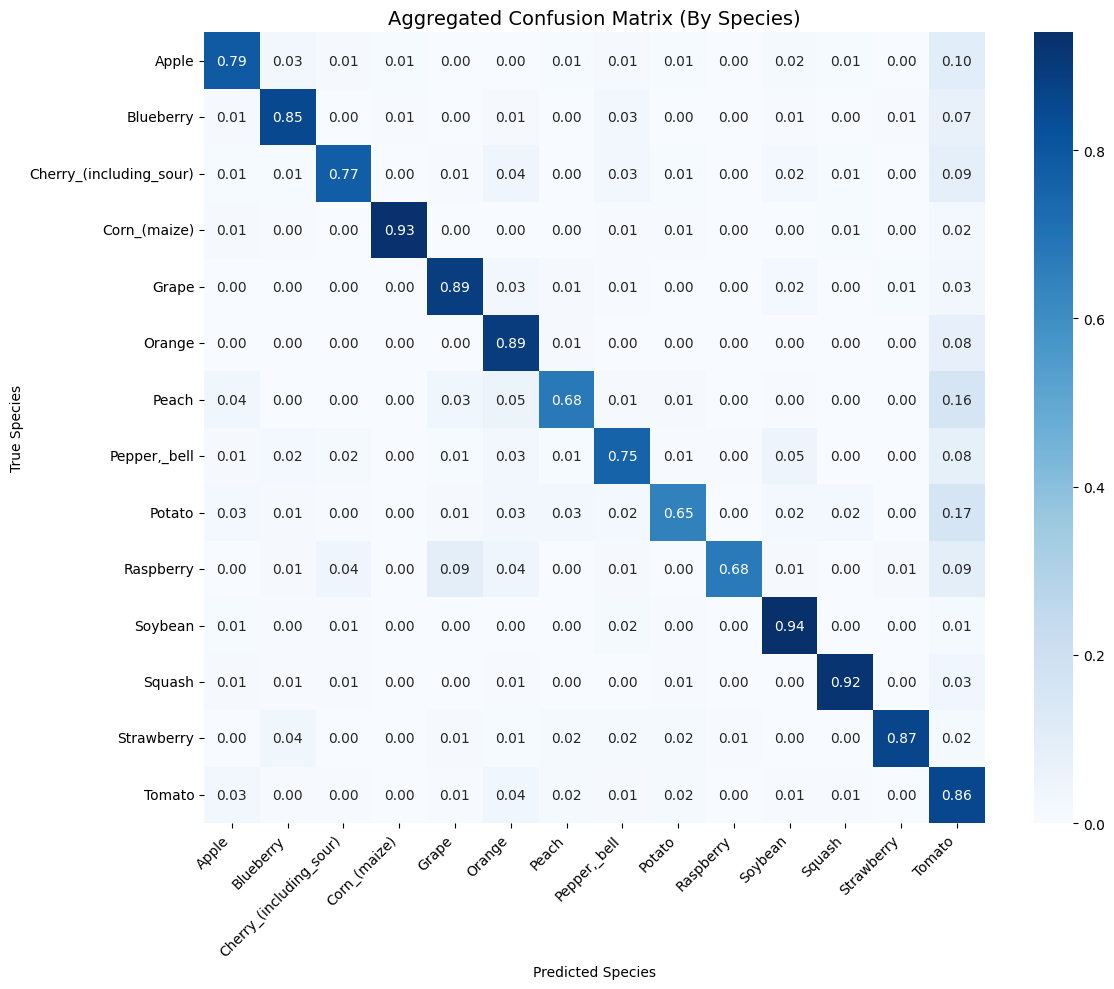

In [15]:
def plot_grouped_matrix(y_true, y_pred):
    # Helper to extract species name
    def get_species(label): return label.split('___')[0]

    y_true_s = [get_species(l) for l in y_true]
    y_pred_s = [get_species(l) for l in y_pred]

    species = sorted(list(set(y_true_s)))
    cm = confusion_matrix(y_true_s, y_pred_s, labels=species)

    # Normalize (Percentage)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=species, yticklabels=species)
    plt.title('Aggregated Confusion Matrix (By Species)', fontsize=14)
    plt.ylabel('True Species')
    plt.xlabel('Predicted Species')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_grouped_matrix(y_test, y_pred)